# LeetCode #35: Search Insert Position

https://leetcode.com/problems/search-insert-position/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Binary Search** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Iterate through the sorted array until finding the first index where `nums[i] >= target`. Returns that index (or `n` if target is larger than all elements). Simple but misses the sorted-array invariant.

### Optimal: Binary Search ★
Maintain `lo` and `hi` pointers. At each step, if `nums[mid] == target` return `mid`; if `nums[mid] < target` move `lo = mid + 1`; else `hi = mid - 1`. When the loop ends, `lo` is exactly where `target` would be inserted to keep the array sorted.

**Why this is better than Brute Force:** $O(\log n)$ vs $O(n)$ — for $n = 10^4$, roughly 14 comparisons vs 10,000.

**Constraints:**
* 1 <= nums.length <= 10^4
* -10^4 <= nums[i] <= 10^4
* nums contains distinct values sorted in ascending order
* -10^4 <= target <= 10^4

## Solutions

### C#

In [ ]:
public class Solution {
    public int SearchInsert(int[] nums, int target) {
        int lo = 0, hi = nums.Length - 1;
        while (lo <= hi) {
            int mid = lo + (hi - lo) / 2;
            if (nums[mid] == target) return mid;
            // Narrow search window toward where target belongs
            if (nums[mid] < target) lo = mid + 1;
            else hi = mid - 1;
        }
        // lo is the leftmost index where nums[lo] >= target
        return lo;
    }
}

### Python

In [ ]:
class Solution:
    def searchInsert(self, nums: list[int], target: int) -> int:
        lo, hi = 0, len(nums) - 1
        while lo <= hi:
            mid = (lo + hi) // 2
            if nums[mid] == target:
                return mid
            # Narrow search window toward where target belongs
            if nums[mid] < target:
                lo = mid + 1
            else:
                hi = mid - 1
        # lo is the leftmost index where nums[lo] >= target
        return lo

### Go

In [ ]:
func searchInsert(nums []int, target int) int {
    lo, hi := 0, len(nums)-1
    for lo <= hi {
        mid := lo + (hi-lo)/2
        if nums[mid] == target {
            return mid
        }
        // Narrow search window toward where target belongs
        if nums[mid] < target {
            lo = mid + 1
        } else {
            hi = mid - 1
        }
    }
    // lo is the leftmost index where nums[lo] >= target
    return lo
}

### Rust

In [ ]:
impl Solution {
    pub fn search_insert(nums: Vec<i32>, target: i32) -> i32 {
        let (mut lo, mut hi) = (0i32, nums.len() as i32 - 1);
        while lo <= hi {
            let mid = lo + (hi - lo) / 2;
            if nums[mid as usize] == target { return mid; }
            // Narrow search window toward where target belongs
            if nums[mid as usize] < target { lo = mid + 1; } else { hi = mid - 1; }
        }
        // lo is the leftmost index where nums[lo] >= target
        lo
    }
}

## Example Scenarios

**1. Common Case**
**Input:** nums = [1, 3, 5, 6], target = 5
lo=0, hi=3 → mid=1, nums[1]=3 < 5 → lo=2. mid=2, nums[2]=5 == 5 → return 2. Direct hit.

**2. Slightly Complex**
**Input:** nums = [1, 3, 5, 6], target = 2
lo=0, hi=3 → mid=1, nums[1]=3 > 2 → hi=0. mid=0, nums[0]=1 < 2 → lo=1. Loop ends. Return lo=1. "2" inserts between 1 and 3.

**3. Edge Case: Time Factor**
**Input:** nums = [1, 2, 3, …, 10^4], target = 10^4 (last element)
Binary search reaches the rightmost element in $\lfloor \log_2 10^4 \rfloor + 1 = 14$ steps. Linear scan would take $10^4$ steps. Maximum iterations for binary search on this input size.

**4. Edge Case: Space Factor**
**Input:** nums = [1], target = 0 (insert before only element)
lo=0, hi=0 → mid=0, nums[0]=1 > 0 → hi=-1. Loop ends. Return lo=0. Single-element array; $O(1)$ extra space regardless of $n$.

**5. Almost-Impossible but Plausible**
**Input:** nums = [1, 3, 5, 6], target = 7 (larger than all elements)
lo=0, hi=3 → mid=1, 3<7 → lo=2. mid=2, 5<7 → lo=3. mid=3, 6<7 → lo=4. Loop ends. Return lo=4 = len(nums). Target goes after all elements — lo naturally overflows to $n$.

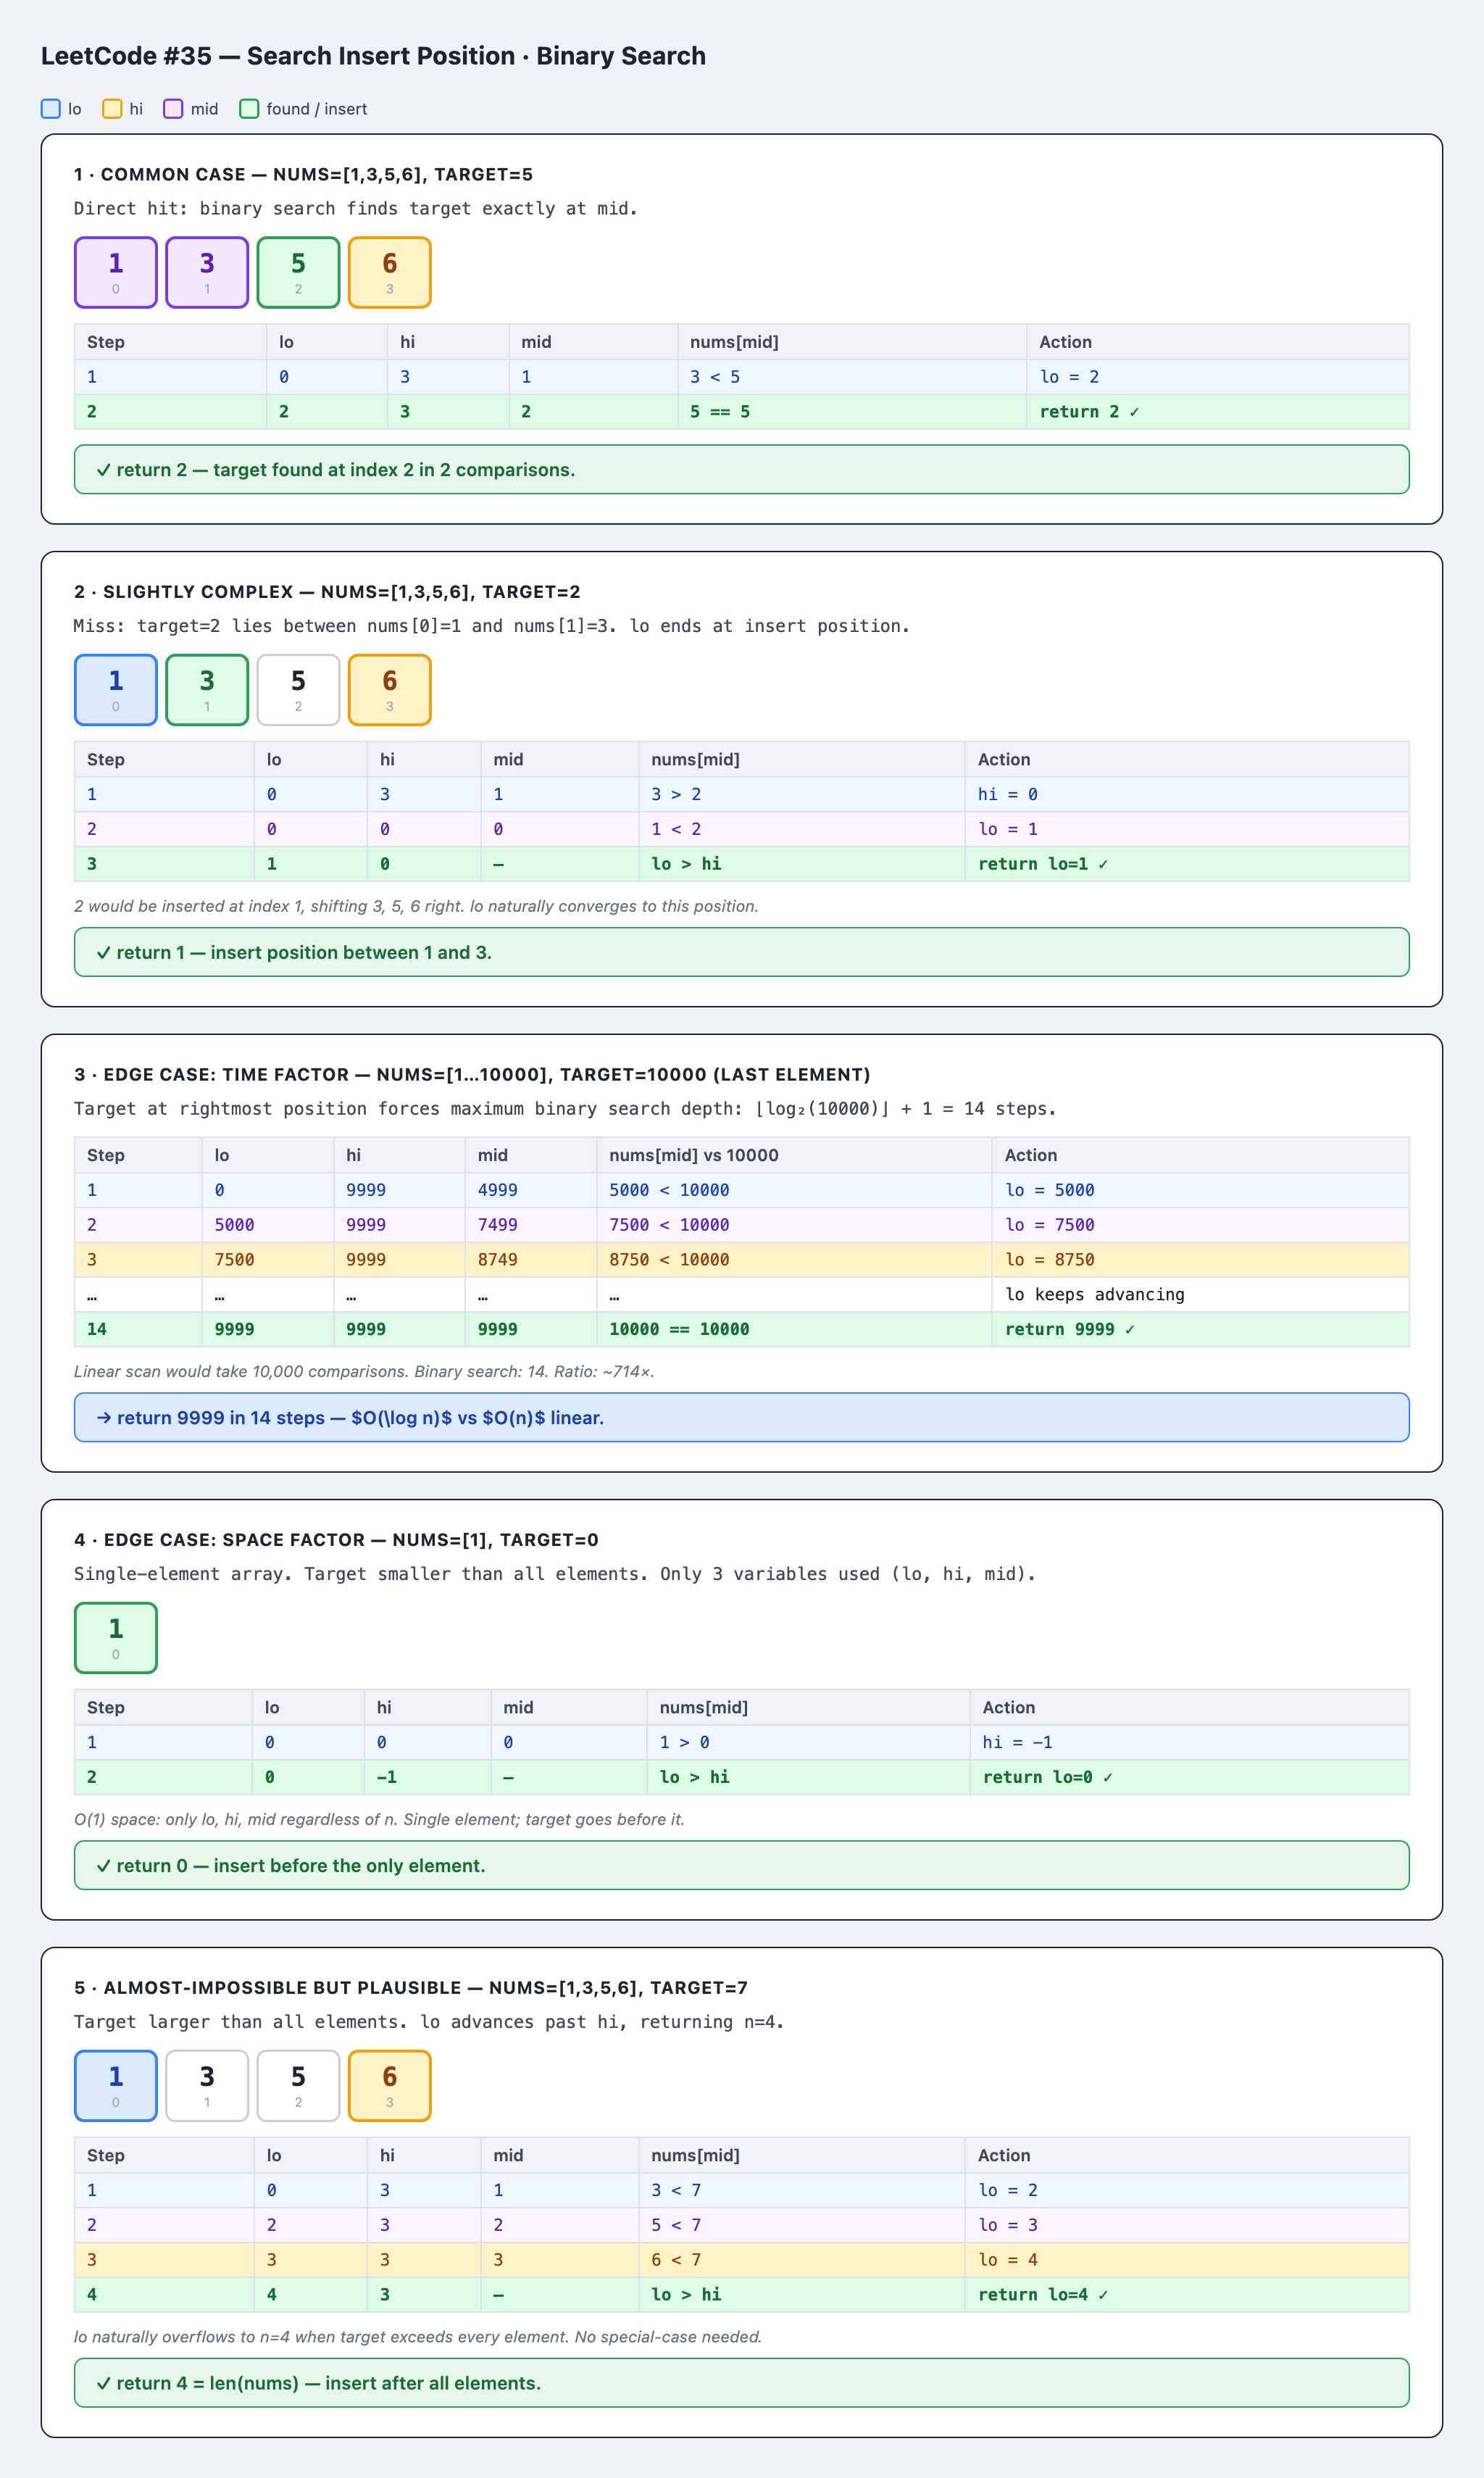